Found 100 CSV files.
Combined predictions DataFrame shape: (131407, 101)
Available model columns: ['submission_Ridge_RandomForest', 'submission_RandomForest_LinearRegression', 'submission_ExtraTrees_DecisionTree', 'submission_Ridge_Lasso', 'submission_DecisionTree_LinearRegression', 'submission_LinearRegression_Lasso', 'submission_DecisionTree_ExtraTrees', 'submission_LightGBM_ExtraTrees', 'submission_RandomForest_CatBoost', 'submission_LightGBM_CatBoost', 'submission_LinearRegression_RandomForest', 'submission_Lasso_CatBoost', 'submission_Lasso_XGBoost', 'submission_DecisionTree_DecisionTree', 'submission_GradientBoosting_LightGBM', 'submission_XGBoost_Lasso', 'submission_XGBoost_Ridge', 'submission_ExtraTrees_XGBoost', 'submission_LightGBM_RandomForest', 'submission_XGBoost_RandomForest', 'submission_ExtraTrees_Ridge', 'submission_RandomForest_RandomForest', 'submission_RandomForest_XGBoost', 'submission_DecisionTree_CatBoost', 'submission_Ridge_DecisionTree', 'submission_Lasso_Extra

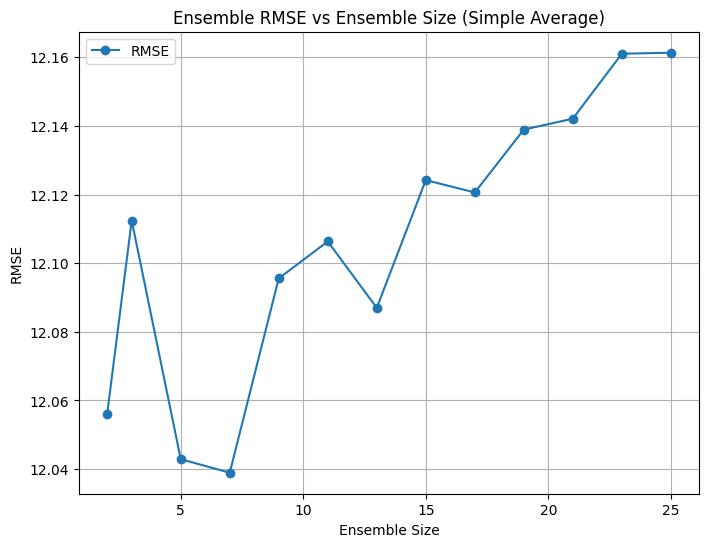

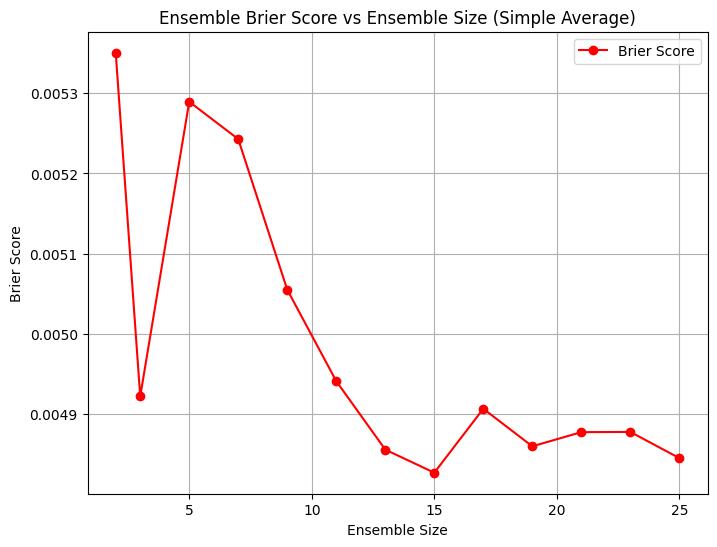

In [1]:
# %% [code]
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Define a helper function to convert margin predictions into win probabilities.
def margin_to_probability(margin, scale=10.0):
    return 1.0 / (1 + 10 ** (-margin / scale))

# Define a function to compute ensemble performance metrics.
def compute_ensemble_scores(pred_df, y_true, model_list, method="simple", combined_rmse_dict=None, scale=10.0):
    if method == "simple":
        ens_margin = pred_df[model_list].mean(axis=1)
    elif method == "weighted":
        if combined_rmse_dict is None:
            raise ValueError("combined_rmse_dict must be provided for weighted ensemble")
        weights = np.array([1 / combined_rmse_dict[m] for m in model_list])
        weights = weights / np.sum(weights)
        ens_margin = np.sum(pred_df[model_list].values * weights, axis=1)
    else:
        raise ValueError("Method not supported.")
    rmse = np.sqrt(mean_squared_error(y_true, ens_margin))
    ens_prob = margin_to_probability(ens_margin, scale=scale)
    # Here we assume that for every game the winning team should have probability 1.
    brier = np.mean((ens_prob - 1) ** 2)
    return rmse, brier

# %% [markdown]
# ## 1. Read and Combine Model Output CSVs (Version 2)
# 
# We now read all CSV files from the folder containing the version‑2 outputs.
# **Change:** The folder path is now set to `/kaggle/input/48-06-super-ensemble/combined_submissions/`.

# %% [code]
# Set the directory containing model output CSVs (version 2)
output_dir = "/kaggle/input/48-06-super-ensemble/combined_submissions"
csv_files = glob.glob(os.path.join(output_dir, "*.csv"))
print(f"Found {len(csv_files)} CSV files.")

# Read each CSV into a dictionary.
dfs = {}
for file in csv_files:
    df = pd.read_csv(file)
    # Ensure the file has an "ID" column. If not, create one using the index.
    if "ID" not in df.columns:
        df["ID"] = df.index
    df.set_index("ID", inplace=True)
    # Rename the "Pred" column to a unique name derived from the filename.
    key = os.path.splitext(os.path.basename(file))[0]
    df.rename(columns={"Pred": key}, inplace=True)
    dfs[key] = df

# Combine all dataframes on the "ID" index.
combined_preds_df = None
for key, df in dfs.items():
    if combined_preds_df is None:
        combined_preds_df = df.copy()
    else:
        combined_preds_df = combined_preds_df.join(df, how="inner")
        
# Reset index so that "ID" becomes a column.
combined_preds_df.reset_index(inplace=True)
print("Combined predictions DataFrame shape:", combined_preds_df.shape)

# %% [markdown]
# ## 2. Create Ensemble Submissions
# 
# We now create ensembles using simple (arithmetic) averaging over different numbers of models.
# We loop over the specified ensemble sizes and, for each size:
# - Select the first N model columns (all columns except "ID").
# - Compute the ensemble prediction.
# - Save the submission file.
# - Compute performance metrics using a dummy ground truth (here, a vector of ones).

# %% [code]
# Define the ensemble sizes to try.
ensemble_sizes = [2, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]

# Create a folder for ensemble submission files.
submission_folder = "ensemble_submissions_v2"
os.makedirs(submission_folder, exist_ok=True)

ensemble_results = []
# Get model prediction column names (exclude "ID").
model_columns = list(combined_preds_df.columns)
if "ID" in model_columns:
    model_columns.remove("ID")

print("Available model columns:", model_columns)

# Create a dummy ground truth vector.
dummy_true = np.ones(combined_preds_df.shape[0])

# Loop over each ensemble size.
for size in ensemble_sizes:
    if len(model_columns) < size:
        print(f"Only {len(model_columns)} models available; skipping ensemble size {size}.")
        continue
    selected_models = model_columns[:size]  # You can modify this selection logic as needed.
    # Compute ensemble predictions (simple average).
    ensemble_preds = combined_preds_df[selected_models].mean(axis=1)
    submission_df = pd.DataFrame({
        "ID": combined_preds_df["ID"],
        "Pred": ensemble_preds
    })
    filename = os.path.join(submission_folder, f"ensemble_top{size}_simple.csv")
    submission_df.to_csv(filename, index=False)
    print(f"Saved submission file: {filename}")
    
    # Compute performance metrics.
    rmse, brier = compute_ensemble_scores(combined_preds_df, dummy_true, selected_models, method="simple", scale=10.0)
    ensemble_results.append({
        "Ensemble": f"top{size}",
        "Method": "simple",
        "RMSE": rmse,
        "Brier": brier
    })

ensemble_scores_df = pd.DataFrame(ensemble_results)
print("Ensemble performance on combined predictions:")
print(ensemble_scores_df)

# %% [markdown]
# ## 3. Visualize Ensemble Performance
# 
# We now plot the RMSE and Brier score versus the ensemble size.

# %% [code]
# Extract ensemble size (numeric) from the "Ensemble" column (e.g., "top2" -> 2).
ensemble_sizes_int = ensemble_scores_df["Ensemble"].str.extract("(\d+)").astype(int)

plt.figure(figsize=(8,6))
plt.plot(ensemble_sizes_int, ensemble_scores_df["RMSE"], marker='o', linestyle='-', label="RMSE")
plt.xlabel("Ensemble Size")
plt.ylabel("RMSE")
plt.title("Ensemble RMSE vs Ensemble Size (Simple Average)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(ensemble_sizes_int, ensemble_scores_df["Brier"], marker='o', linestyle='-', color='red', label="Brier Score")
plt.xlabel("Ensemble Size")
plt.ylabel("Brier Score")
plt.title("Ensemble Brier Score vs Ensemble Size (Simple Average)")
plt.legend()
plt.grid(True)
plt.show()